In [8]:
#menghubungkan colab dengan google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
path = "/content/drive/MyDrive/Kuliah/Semester 7/Machine Learning/Praktikum/praktikum kelas/praktikum kelas 07/data"

In [10]:
#membaca file csv menggunakan pandas
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Kuliah/Semester 7/Machine Learning/Praktikum/praktikum kelas/praktikum kelas 07/data/dataset_satelit.csv")
df

,No,Longitude,Lattitude,N,P,K,Ca,Mg,Fe,Mn,...,b1,Sigma_VV,Sigma_VH,plia,lia,iafe,gamma0_vv,gamma0_vh,beta0_vv,beta0_vh
0,1,103.036658,-0.604417,2.64,0.15,0.415,0.51,0.31,119.96,463.23,...,0.0433,0.18183,0.04461,35.74446,35.79744,35.41161,0.22331,0.05479,0.31325,0.07686
1,2,103.037201,-0.604689,2.75,0.17,0.568,0.76,0.58,102.63,493.81,...,0.0465,0.22079,0.04640,35.12096,35.14591,35.41510,0.27116,0.05699,0.38033,0.07993
2,3,103.036359,-0.603012,1.77,0.12,0.339,0.49,0.6,107.37,460.93,...,0.0417,0.18926,0.03992,35.07724,35.07730,35.41135,0.23242,0.04902,0.32604,0.06876
3,4,103.036950,-0.603219,2.30,0.15,0.460,0.74,0.67,96.02,338.17,...,0.0367,0.14769,0.03622,36.08078,36.08469,35.41583,0.18138,0.04448,0.25440,0.06238
4,5,103.036802,-0.601969,2.05,0.14,0.308,0.64,0.72,87.01,384.33,...,0.0361,0.18205,0.03797,32.68855,32.69293,35.41592,0.22359,0.04664,0.31359,0.06541
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
589,590,103.605867,0.057633,2.49,0.16,0.347,0.78,0.86,63.38,269.95,...,0.2336,0.13050,0.09390,0.12700,0.09860,0.02600,0.00870,0.01690,0.00930,0.01630
590,591,103.606717,0.057100,2.74,0.15,0.466,0.73,0.5,51.04,683.42,...,0.2506,0.21280,0.15920,0.20060,0.14730,0.03870,0.01380,0.02290,0.01270,0.01640
591,592,103.606250,0.056767,2.63,0.15,0.422,0.82,0.59,82.57,396.18,...,0.3413,0.27730,0.17820,0.25790,0.18690,0.04620,0.01250,0.02250,0.01600,0.01930
592,593,103.606400,0.056517,2.75,0.17,0.502,0.69,0.53,102.07,246.35,...,0.3413,0.32740,0.28760,0.29970,0.22250,0.05290,0.01800,0.03350,0.01790,0.01930


In [19]:
# 1. Import Library
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
# 2. Membersihkan kolom: drop Longitude/Latitude & kolom nomor; set target = N
geo_keys = ['longitude','longitude_deg','lon','long','lng','latitude','lat']
drop_geo = [c for c in df.columns if any(k in c.lower() for k in geo_keys)]
num_keys = ['no','nomor','index','id']
drop_num = [c for c in df.columns if c.lower() in num_keys]
df = df.drop(columns=list(set(drop_geo + drop_num)), errors='ignore')

# Target = kolom N
target_col = 'N'
assert target_col in df.columns, "Kolom 'N' tidak ditemukan!"

# Encode N bila berupa 'Y'/'N'
if df[target_col].dtype == 'object':
    vals = df[target_col].astype(str).str.upper().str.strip()
    if set(vals.unique()) <= {'Y','N'}:
        df[target_col] = (vals == 'Y').astype(int)  # Y→1, N→0
    else:
        le = LabelEncoder()
        df[target_col] = le.fit_transform(vals)

print("Distribusi label:\n", df[target_col].value_counts())

Distribusi label:
 N
2.59    14
2.36     9
2.42     9
2.41     8
2.68     8
        ..
2.80     1
3.06     1
2.92     1
3.23     1
2.88     1
Name: count, Length: 161, dtype: int64


In [13]:
# 3. Memisahkan X dan y
X = df.drop(columns=[target_col])
y = df[target_col]

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
print("Fitur numerik :", num_cols[:10], "..." if len(num_cols)>10 else "")
print("Fitur kategorik:", cat_cols[:10], "..." if len(cat_cols)>10 else "")

Fitur numerik : ['P', 'K', 'Ca', 'Fe', 'Mn', 'Cu', 'Zn', 'B', 'b12', 'b11'] ...
Fitur kategorik: ['Mg'] 


In [14]:
# 4. Preprocessing & split (X_train, X_test, y_train, y_test)
numeric_tf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categoric_tf = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer([
    ("num", numeric_tf, num_cols),
    ("cat", categoric_tf, cat_cols)
], remainder="drop")

# stratify supaya proporsi kelas terjaga (kalau memungkinkan)
use_stratify = y.value_counts().min() >= 2
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y if use_stratify else None
)

In [16]:
# 5.Latih Linear Regression
from sklearn.linear_model import LinearRegression

linreg = Pipeline([
    ("prep", preprocess),
    ("reg", LinearRegression())
])

linreg.fit(X_train, y_train)
print("Model Linear Regression terlatih.")

Model Linear Regression terlatih.


In [17]:
# 6. Evaluasi hasil regresi
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = linreg.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

MAE : 0.1793
RMSE: 0.2305
R²  : 0.6492


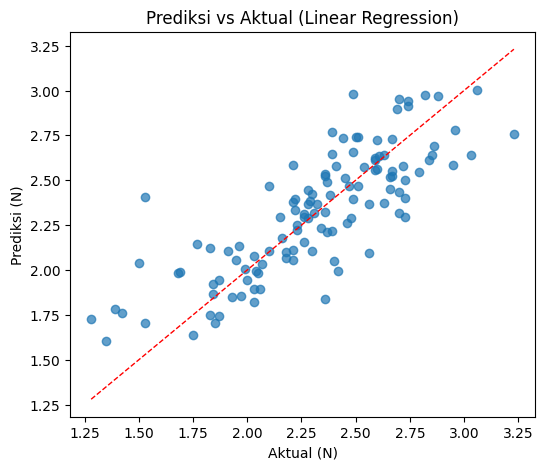

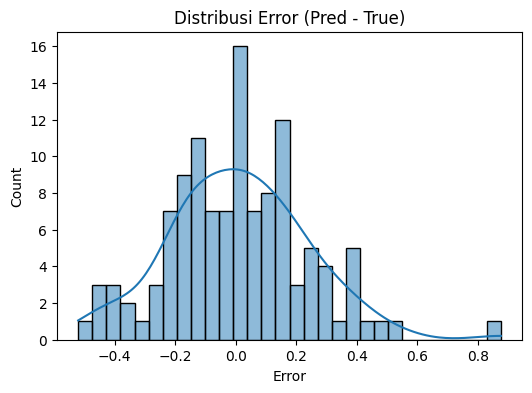

In [18]:
# 7. Visualisasi Prediksi vs Aktual
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Aktual (N)")
plt.ylabel("Prediksi (N)")
plt.title("Prediksi vs Aktual (Linear Regression)")
lim = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lim, lim, 'r--', linewidth=1)
plt.show()

err = y_pred - y_test
plt.figure(figsize=(6,4))
sns.histplot(err, bins=30, kde=True)
plt.title("Distribusi Error (Pred - True)")
plt.xlabel("Error")
plt.show()